In [1]:
%matplotlib ipympl
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection

In [2]:
geom_data = np.load('detector_cuboids.npz')
plate_geoms = geom_data['plate cuboids']
xtal_geoms = geom_data['crystal cuboids']

In [3]:
def get_verts_2d_from_cuboids(cuboids):
    print(cuboids.shape)
    cuboids = torch.tensor(cuboids).reshape(-1, 4, 3)
    return torch.stack(
        [
            cuboids[:, 0, :2]
            - 0.5 * cuboids[:, 1, :2]
            - 0.5 * cuboids[:, 2, :2],
            cuboids[:, 0, :2]
            - 0.5 * cuboids[:, 1, :2]
            + 0.5 * cuboids[:, 2, :2],
            cuboids[:, 0, :2]
            + 0.5 * cuboids[:, 1, :2]
            + 0.5 * cuboids[:, 2, :2],
            cuboids[:, 0, :2]
            + 0.5 * cuboids[:, 1, :2]
            - 0.5 * cuboids[:, 2, :2],
        ],
        dim=1,
    )

In [4]:
xtal_geoms_verts_2d = get_verts_2d_from_cuboids(xtal_geoms)
plate_geoms_verts_2d = get_verts_2d_from_cuboids(plate_geoms)

(6, 144, 4, 3)
(6, 12, 4, 3)


In [ ]:
print(xtal_geoms_verts_2d.shape)
print(plate_geoms_verts_2d.shape)

torch.Size([864, 4, 2])
torch.Size([72, 4, 2])


In [5]:
data = []
for igeom, geom in enumerate(plate_geoms_verts_2d):
    for ivert, vert in enumerate(geom):
        data.append([igeom, 0, ivert, vert[0], vert[1]])

for igeom, geom in enumerate(xtal_geoms_verts_2d):
    for ivert, vert in enumerate(geom):
        data.append(
            [igeom + plate_geoms_verts_2d.shape[0], 1, ivert, vert[0], vert[1]]
        )
data = torch.tensor(data)
# Create the DataFrame with header
df = pd.DataFrame(
    data, columns=["geometry id", "flag", "vertex id", "vertex x", "vertex y"]
)
df.to_hdf("scanner_verts_2d.hdf5", key="verts", mode="w")

In [6]:
from raytracer_2d import (
    get_rect_subdivs,
    get_rects_center_2d,
    get_rects_verts_2d,
    get_fov_pixel_centers_2d,
    get_rays_2d,
    get_fov_verts_2d,
    get_convex_hull_2d,
    get_furthest_corners,
    get_verts_sorted_by_angel_2d,
	get_cuts_ray_on_edges_2d
)

from raytracer_2d import plot_rects, plot_scanner_2d

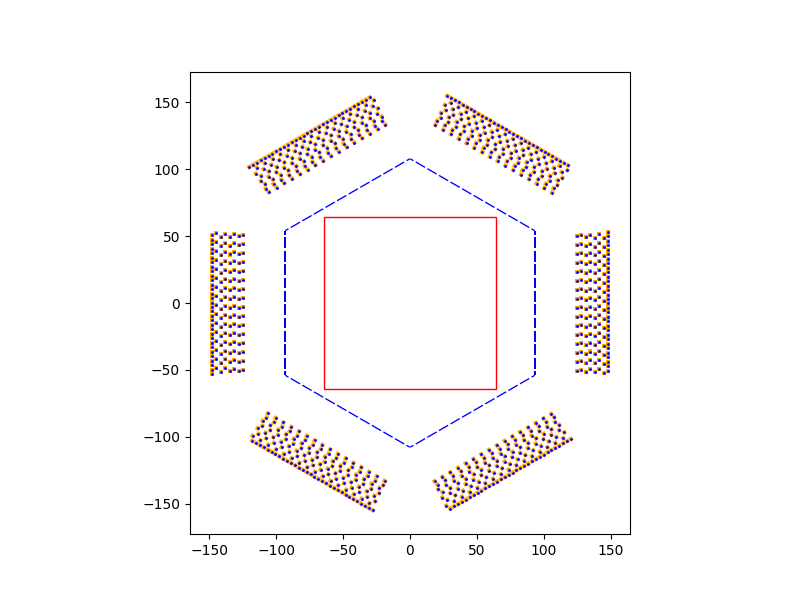

In [7]:
fov_n_pixels_tensor = torch.tensor([32, 32])
fov_mm_per_pixel_tensor = torch.tensor([4, 4])
fov_dim = fov_n_pixels_tensor * fov_mm_per_pixel_tensor
fov_center = torch.tensor([0.0, 0.0])

pa_tensor = get_fov_pixel_centers_2d(
    fov_n_pixels_tensor, fov_mm_per_pixel_tensor, fov_center
)
pb_tensor = xtal_geoms_verts_2d.mean(dim=1)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
for i in range(xtal_geoms_verts_2d.shape[0]):
    ax.add_patch((Polygon(xtal_geoms_verts_2d[i], ec="none", fc="orange")))
for i in range(plate_geoms_verts_2d.shape[0]):
    ax.add_patch((Polygon(plate_geoms_verts_2d[i], ec="none", fc="blue")))

fov_corners = get_fov_verts_2d(fov_dim)
ax.add_patch((Polygon(fov_corners, ec="red",fc="none")))
# ax.add_patch
# ax.scatter(
#     pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1],s=1 ,color="red"
# )
ax.scatter(pb_tensor[:, 0], pb_tensor[:, 1], s=1, color="blue")
ax.autoscale()
ax.set_aspect("equal")
plt.show()

In [ ]:
def if_rects_in_hull_2d(
    geoms_verts_2d: list[torch.Tensor], hull
) -> torch.Tensor:
    n_hull = hull.shape[0]
    out = []
    for i_geom, geom_verts in enumerate(geoms_verts_2d):
        n_verts = geom_verts.shape[0]
        p0_tensor = hull.unsqueeze(0).expand(n_verts, n_hull, 2)
        p1_tensor = (
            torch.vstack([hull[1:], hull[0]])
            .unsqueeze(0)
            .expand(n_verts, n_hull, 2)
        )
        p2_tensor = geom_verts.unsqueeze(1).expand(n_verts, n_hull, 2)
        v1 = p1_tensor - p0_tensor
        v2 = p2_tensor - p0_tensor
        cross = torch.sign(
            v2[:, :, 0] * v1[:, :, 1] - v2[:, :, 1] * v1[:, :, 0]
        ).view(n_verts, n_hull)
        if torch.logical_or(
            (cross >= 0).all(dim=1), (cross <= 0).all(dim=1)
        ).all():
            out.append(i_geom)
    return torch.tensor(out)

def if_rects_intersect_hull_2d(
    geoms_edges_2d, edges_indices, hull, xtal_center
) -> torch.Tensor:
    verts, _ = get_verts_sorted_by_angel_2d(hull, xtal_center)
    rays = get_rays_2d(verts[[1, -1]], xtal_center.view(1, 2)).view(-1, 2, 2)
    _, index = get_cuts_ray_on_edges_2d(rays, geoms_edges_2d)
    return torch.unique(edges_indices[index[:, 1]][:, 0])


def get_cuts_ray_on_edges_2d(
    rays: torch.Tensor,
    edges: torch.Tensor,
):
    """
    Cut rays with line segments (edges)
    """
    # rays shape (number rays, 2, 2)
    # `number of end points` is always 1
    # edges shape (n_edges, 2, 2)
    n_rays = rays.shape[0]
    n_edges = edges.shape[0]
    print(n_rays, n_edges)
    v1 = (rays[:, 1] - rays[:, 0]).unsqueeze(1).expand(-1, n_edges, -1)
    v2 = (edges[:, 0] - edges[:, 1]).unsqueeze(0).expand(n_rays, -1, -1)
    v3 = edges[:, 0].unsqueeze(0).expand(n_rays, -1, -1) - rays[:, 0].view(
        n_rays, 1, 2
    ).expand(-1, n_edges, -1)

    # cramer's rule
    # v1, v2, v3 shape (n_pa, n_rects, 4, 2)
    # det shape (n_pa, n_rects, 4)
    det = v1[:, :, 0] * v2[:, :, 1] - v1[:, :, 1] * v2[:, :, 0]
    t = torch.where(
        det != 0,
        (v3[:, :, 0] * v2[:, :, 1] - v2[:, :, 0] * v3[:, :, 1]) / det,
        float("nan"),
    )
    s = torch.where(
        det != 0,
        (v1[:, :, 0] * v3[:, :, 1] - v1[:, :, 1] * v3[:, :, 0]) / det,
        float("nan"),
    )
    t = torch.where((s <= 1) * (s >= 0) * (t <= 1) * (t >= 0), t, float("nan"))
    index = torch.argwhere(~torch.isnan(t))
    return t, index

In [45]:
# pixel_corners = get_furthest_corners(pa_tensor.view(-1, 2))
def get_edges_from_verts_2d(
    geoms_verts: list[torch.Tensor],
) -> tuple[torch.Tensor, torch.Tensor]:
    out = torch.empty((0, 2, 2), dtype=torch.float32)
    index = torch.empty((0, 2), dtype=torch.int64)
    for i_geom, geom_verts in enumerate(geoms_verts):
        out = torch.vstack(
            [
                out,
                torch.stack(
                    [
                        geom_verts,
                        torch.vstack(
                            [geom_verts[1:], geom_verts[0].view(1, 2)]
                        ),
                    ],
                    dim=1,
                ),
            ]
        )
        index = torch.vstack(
            [
                index,
                torch.stack(
                    [
                        torch.ones(geom_verts.shape[0], dtype=torch.int64)
                        * i_geom,
                        torch.arange(geom_verts.shape[0]),
                    ],
                    dim=1,
                ),
            ]
        )
    return out, index


geoms_verts_2d = []
for geom in plate_geoms_verts_2d:
    geoms_verts_2d.append(geom)
for geom in xtal_geoms_verts_2d:
    geoms_verts_2d.append(geom)
# geoms_verts_2d = torch.vstack((plate_geoms_verts_2d, xtal_geoms_verts_2d))
geoms_edges_2d, edge_indices = get_edges_from_verts_2d(geoms_verts_2d)
print(geoms_edges_2d.shape)
print(edge_indices.shape)
# edge_indices = torch.arange(geoms_edges_2d.shape[0]).unsqueeze(1).expand(-1, 4)
# print(edge_indices.shape)
# print(geoms_edges_2d.shape)
pixel_corners = get_furthest_corners(pa_tensor.view(-1, 2))
hull = get_convex_hull_2d(torch.vstack((pb_tensor[0], pixel_corners)))


torch.Size([3744, 2, 2])
torch.Size([3744, 2])


In [ ]:
def if_rects_in_hull_2d(
    geoms_verts_2d: list[torch.Tensor], hull
) -> torch.Tensor:
    n_hull = hull.shape[0]
    out = []
    for i_geom, geom_verts in enumerate(geoms_verts_2d):
        n_verts = geom_verts.shape[0]
        p0_tensor = hull.unsqueeze(0).expand(n_verts, n_hull, 2)
        p1_tensor = (
            torch.vstack([hull[1:], hull[0]])
            .unsqueeze(0)
            .expand(n_verts, n_hull, 2)
        )
        p2_tensor = geom_verts.unsqueeze(1).expand(n_verts, n_hull, 2)
        v1 = p1_tensor - p0_tensor
        v2 = p2_tensor - p0_tensor
        cross = torch.sign(
            v2[:, :, 0] * v1[:, :, 1] - v2[:, :, 1] * v1[:, :, 0]
        ).view(n_verts, n_hull)
        if torch.logical_or(
            (cross >= 0).all(dim=1), (cross <= 0).all(dim=1)
        ).all():
            out.append(i_geom)
    return torch.tensor(out)

geoms_edges_2d, edge_indices = get_edges_from_verts_2d(geoms_verts_2d)
pixel_corners = get_furthest_corners(pa_tensor.view(-1, 2))
insid_indices = []
intsc_indices = []
hulls = []
i_list = torch.arange(xtal_geoms_verts_2d.shape[0])
for i in i_list:
    hull = get_convex_hull_2d(torch.vstack((pb_tensor[i], pixel_corners)))
    local_intsc_indices = if_rects_intersect_hull_2d(
        geoms_edges_2d, edge_indices, hull, pb_tensor[i]
    )
    local_intsc_indices = local_intsc_indices[~local_intsc_indices.eq(i)]
    intsc_indices.append(local_intsc_indices.tolist())
    insid_indices.append(if_rects_in_hull_2d(geoms_verts_2d, hull))
    hulls.append(hull)

2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.Size([2, 3744])
2 3744
torch.S

torch.Size([936, 4, 2])


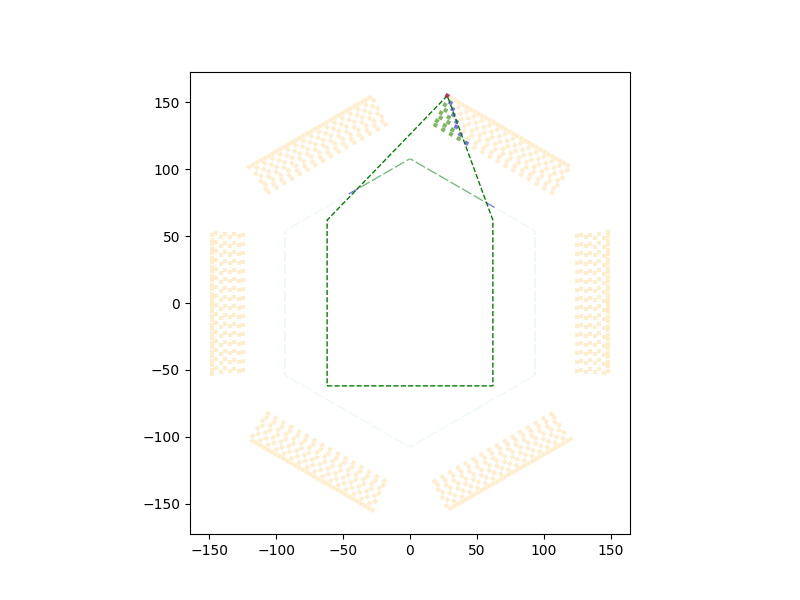

In [67]:
try:
    plt.close()
except Exception as e:
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
xtal_rects_pcoll = PolyCollection(
    xtal_geoms_verts_2d.tolist(), ec="none", fc="orange", alpha=0.2
)
plate_rects_pcoll = PolyCollection(
    plate_geoms_verts_2d.tolist(), ec="none", fc="lightblue",alpha=0.2
)
ax.add_collection(plate_rects_pcoll)
all_geoms_verts_2d = torch.vstack([plate_geoms_verts_2d, xtal_geoms_verts_2d])
ax.add_collection(xtal_rects_pcoll)
print(all_geoms_verts_2d.shape)
rects_inter = all_geoms_verts_2d[1:6]
rects_insid = all_geoms_verts_2d[:1]
rects_inter_pcoll = PolyCollection(
    rects_inter.tolist(), fc="blue", alpha=0.5, visible=False   
)
rects_insid_pcoll = PolyCollection(
    rects_insid.tolist(), fc="green", alpha=0.5, visible=False
)
ax.add_collection(rects_inter_pcoll)
ax.add_collection(rects_insid_pcoll)
hull_poly = Polygon(
    hulls[0],
    closed=True,
    fill=None,
    edgecolor="green",
    linestyle="--",
    linewidth=1,
)
focused_rects_polygon = Polygon(
    xtal_geoms_verts_2d[0], closed=True, fc="r", ec="none", alpha=0.5
)
ax.add_patch(hull_poly)
ax.add_patch(focused_rects_polygon)
ax.autoscale()
for i in torch.arange(xtal_geoms_verts_2d.shape[0]):
# for i in torch.arange(1):
    hull_poly.set_xy(hulls[i])
    rects_insid_pcoll.set_verts(all_geoms_verts_2d[insid_indices[i]].tolist())
    rects_inter_pcoll.set_verts(all_geoms_verts_2d[intsc_indices[i]].tolist())
    rects_insid_pcoll.set_visible(True)
    rects_inter_pcoll.set_visible(True)
    focused_rects_polygon.set_xy(xtal_geoms_verts_2d[i])
    fig.savefig(f"outputs/images/hulls/xtal_{i}.png")